# Financial Portfolio Analytics & Optimization

## Exploratory Analysis and Mean-Variance Optimization

This notebook analyzes the historical risk-return characteristics of three asset classes represented by exchange-traded funds:

- **MSCI World:** URTH
- **Emerging Markets:** IEMG
- **Gold:** GLD

The analysis covers the period from January 2015 to September 2026 and includes data cleaning, return analysis, risk metrics, diversification, Monte Carlo portfolio simulation, and mean-variance optimization based on Modern Portfolio Theory.

> Historical performance is used for analytical purposes only and should not be interpreted as a prediction of future returns.

## 1. Setup and Libraries

The analysis uses Python libraries for data manipulation, numerical computation, visualization, market data retrieval, and numerical optimization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

## 2. Data Acquisition

Historical daily market data is retrieved using `yfinance`.

The selected ETFs are used as proxies for three broad asset classes:

- **URTH:** developed global equities (MSCI World)
- **IEMG:** emerging-market equities
- **GLD:** gold

The sample period is fixed to ensure that the analysis remains reproducible when the notebook is executed in the future.

In [2]:
tickers = ["URTH", "IEMG", "GLD"]

data = yf.download(
    tickers,
    start="2015-01-01",
    end="2026-09-25",
    auto_adjust=True,
    progress=False
)

In [3]:
prices = data["Close"].rename(
    columns={
        "URTH": "World",
        "IEMG": "Emerging Markets",
        "GLD": "Gold"
    }
)

prices.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-02,114.080002,34.404835,57.947823
2015-01-05,115.800003,33.880531,56.589092
2015-01-06,117.120003,33.703293,55.836960
2015-01-07,116.430000,34.397449,56.403088
2015-01-08,115.940002,35.010372,57.656673


## 3. Data Cleaning

The closing-price dataset is inspected for missing observations before calculating returns.

A missing observation was identified for some assets during the sample period. Since portfolio analysis requires aligned observations across all assets, rows containing incomplete price data are removed.

The original dataset is retained separately to preserve the raw data.

In [4]:
prices.isnull().sum()

prices_clean = prices.dropna()

prices_clean.isnull().sum()

Ticker
Gold                0
Emerging Markets    0
World               0
dtype: int64

## 4. Returns and Performance Metrics

Daily returns are calculated from adjusted closing prices. These returns are then used to evaluate cumulative performance, annualized growth, and volatility for each asset.

The analysis distinguishes between:

- **Total Return:** cumulative growth over the full sample period
- **CAGR:** annualized compound growth rate
- **Annual Volatility:** annualized standard deviation of daily returns

In [5]:
returns = prices_clean.pct_change()
returns_clean = returns.dropna()

returns.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,0.015077,-0.015239,-0.023447
2015-01-06,0.011399,-0.005231,-0.013291
2015-01-07,-0.005891,0.020596,0.010139
2015-01-08,-0.004209,0.017819,0.022225


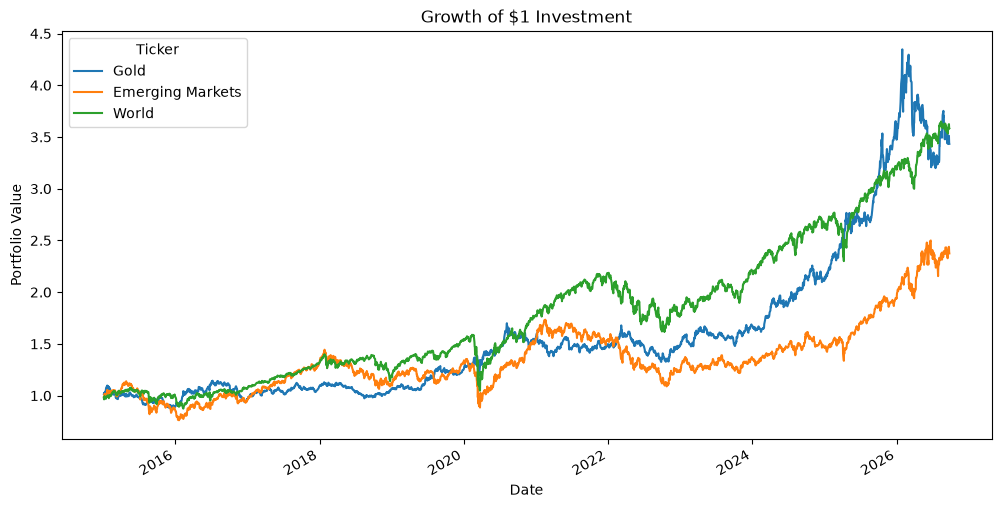

In [6]:
cumulative_returns = (1 + returns_clean).cumprod()

cumulative_returns.plot(
    figsize=(12, 6),
    title="Growth of $1 Investment"
)

plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.show()

In [7]:
total_returns = (
    cumulative_returns.iloc[-1] - 1
) * 100

total_returns

Ticker
Gold                243.346771
Emerging Markets    137.466616
World               258.339597
Name: 2026-09-24 00:00:00, dtype: float64

In [8]:
start_date = prices_clean.index[0]
end_date = prices_clean.index[-1]

years = (end_date - start_date).days / 365.25

final_values = cumulative_returns.iloc[-1]

cagr = final_values ** (1 / years) - 1

cagr * 100

Ticker
Gold                11.093021
Emerging Markets     7.654209
World               11.498676
Name: 2026-09-24 00:00:00, dtype: float64

In [9]:
annual_volatility = (
    returns_clean.std() * np.sqrt(252)
)

annual_volatility * 100

Ticker
Gold                16.237921
Emerging Markets    20.461664
World               17.097656
dtype: float64

In [10]:
summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "CAGR (%)": cagr * 100,
    "Annual Volatility (%)": annual_volatility * 100
})

summary

,Total Return (%),CAGR (%),Annual Volatility (%)
Ticker,,,
Gold,243.346771,11.093021,16.237921
Emerging Markets,137.466616,7.654209,20.461664
World,258.339597,11.498676,17.097656


### Interpretation

Over the selected sample period:

- **MSCI World** achieved the highest cumulative and annualized return.
- **Gold** delivered a similar CAGR with slightly lower annual volatility.
- **Emerging Markets** exhibited the lowest annualized return and the highest volatility of the three assets.

These results describe historical performance within the selected period and should not be interpreted as forecasts of future returns.

## 5. Correlation and Diversification

Portfolio risk depends not only on the volatility of individual assets, but also on how their returns move relative to one another.

Correlation is used to measure the linear relationship between asset returns:

- A correlation close to **+1** indicates that two assets tend to move in the same direction.
- A correlation close to **0** indicates a weak linear relationship.
- A correlation close to **-1** indicates that two assets tend to move in opposite directions.

Low correlation between assets can reduce overall portfolio volatility through diversification.

In [11]:
correlation_matrix = returns_clean.corr()

correlation_matrix

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,1.000000,0.213885,0.112291
Emerging Markets,0.213885,1.000000,0.803396
World,0.112291,0.803396,1.000000


### Correlation Analysis

The correlation matrix reveals two important relationships:

- **MSCI World and Emerging Markets** show a relatively high positive correlation, indicating that their daily returns often move in the same direction.
- **Gold** shows a much lower correlation with both equity markets, particularly with MSCI World.

This suggests that gold may provide stronger diversification benefits when combined with global equities.

In [12]:
cov_matrix_annual = (
    returns_clean.cov() * 252
)

cov_matrix_annual

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,0.026367,0.007106,0.003118
Emerging Markets,0.007106,0.041868,0.028107
World,0.003118,0.028107,0.029233


### 70/20/10 Reference Portfolio

A simple reference portfolio is constructed using:

- **70% MSCI World**
- **20% Emerging Markets**
- **10% Gold**

This portfolio is not assumed to be optimal. It is used as a benchmark to illustrate the effect of diversification and to compare later with optimized portfolios.

In [13]:
weights = pd.Series({
    "Gold": 0.10,
    "Emerging Markets": 0.20,
    "World": 0.70
})

assert np.isclose(weights.sum(), 1.0)

weights

Gold                0.1
Emerging Markets    0.2
World               0.7
dtype: float64

In [14]:
portfolio_returns = returns_clean @ weights

portfolio_growth = (
    1 + portfolio_returns
).cumprod()


In [15]:
portfolio_total_return = (
    portfolio_growth.iloc[-1] - 1
) * 100

portfolio_cagr = (
    portfolio_growth.iloc[-1] ** (1 / years)
) - 1

portfolio_annual_mean_return = (
    portfolio_returns.mean() * 252
)

portfolio_70_20_10_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

portfolio_total_return, portfolio_cagr, portfolio_70_20_10_volatility

(np.float64(241.66976793683713),
 np.float64(0.1104664413490084),
 np.float64(0.15764863812642285))

In [16]:
portfolio_sharpe = (
    portfolio_annual_mean_return /
    portfolio_70_20_10_volatility
)

annual_mean_return = (
    returns_clean.mean() * 252
)

asset_sharpe = (
    annual_mean_return /
    annual_volatility
)

In [17]:
portfolio_summary = pd.DataFrame({
    "Total Return (%)": [
        portfolio_total_return
    ],
    "CAGR (%)": [
        portfolio_cagr * 100
    ],
    "Annual Volatility (%)": [
        portfolio_70_20_10_volatility * 100
    ],
    "Sharpe (Rf=0)": [
        portfolio_sharpe
    ]
}, index=["70/20/10 Portfolio"])

portfolio_summary

,Total Return (%),CAGR (%),Annual Volatility (%),Sharpe (Rf=0)
70/20/10 Portfolio,241.669768,11.046644,15.764864,0.74553


In [18]:
summary["Sharpe (Rf=0)"] = asset_sharpe

summary

,Total Return (%),CAGR (%),Annual Volatility (%),Sharpe (Rf=0)
Ticker,,,,
Gold,243.346771,11.093021,16.237921,0.730941
Emerging Markets,137.466616,7.654209,20.461664,0.464194
World,258.339597,11.498676,17.097656,0.724129


### Diversification Effect

The 70/20/10 portfolio achieved lower annualized volatility than any of the three assets individually.

This reduction in risk is explained by diversification: gold exhibited a low historical correlation with global equity markets, allowing part of the fluctuations in the equity allocation to be offset.

The portfolio therefore illustrates that portfolio volatility is not simply the weighted average of individual asset volatilities. Covariances between assets also play a central role.

In [19]:
portfolio_volatility_matrix = np.sqrt(
    weights @ cov_matrix_annual @ weights
)

portfolio_volatility_matrix * 100

np.float64(15.764863812642286)

The portfolio volatility obtained from the covariance matrix matches the volatility calculated directly from the portfolio return series, confirming the mean-variance formulation.

## 6. Monte Carlo Portfolio Simulation

A Monte Carlo simulation is used to explore a large number of possible portfolio allocations.

For each randomly generated portfolio:

- Asset weights are normalized so that they sum to 100%.
- Expected annual return is calculated from historical mean returns.
- Portfolio volatility is calculated using the annualized covariance matrix.
- A simplified Sharpe ratio is computed assuming a risk-free rate of 0%.

The simulation provides a visual approximation of the portfolio risk-return opportunity set.

In [20]:
expected_returns = returns_clean.mean() * 252
cov_matrix = returns_clean.cov() * 252

In [21]:
np.random.seed(42)

n_portfolios = 10000
portfolio_results = []

for _ in range(n_portfolios):

    random_weights = np.random.random(len(expected_returns))
    random_weights /= random_weights.sum()

    portfolio_return_random = (
        random_weights @ expected_returns.values
    )

    portfolio_volatility_random = np.sqrt(
        random_weights @ cov_matrix.values @ random_weights
    )

    portfolio_sharpe_random = (
        portfolio_return_random /
        portfolio_volatility_random
    )

    portfolio_results.append({
        "Gold Weight": random_weights[0],
        "Emerging Markets Weight": random_weights[1],
        "World Weight": random_weights[2],
        "Return": portfolio_return_random,
        "Volatility": portfolio_volatility_random,
        "Sharpe": portfolio_sharpe_random
    })

In [22]:
portfolios = pd.DataFrame(portfolio_results)

portfolios.head()

,Gold Weight,Emerging Markets Weight,World Weight,Return,Volatility,Sharpe
0,0.182059,0.462129,0.355812,0.109555,0.156074,0.701941
1,0.657381,0.171323,0.171296,0.115505,0.132037,0.874795
2,0.038078,0.567845,0.394077,0.107245,0.176233,0.608538
3,0.416865,0.012119,0.571017,0.121326,0.126747,0.957228
4,0.678655,0.173111,0.148234,0.115344,0.133343,0.865019


In [23]:
max_sharpe_idx = portfolios["Sharpe"].idxmax()
max_sharpe_portfolio_mc = portfolios.loc[max_sharpe_idx]

min_vol_idx = portfolios["Volatility"].idxmin()
min_vol_portfolio_mc = portfolios.loc[min_vol_idx]

In [24]:
monte_carlo_summary = pd.DataFrame({
    "Maximum Sharpe": max_sharpe_portfolio_mc,
    "Minimum Volatility": min_vol_portfolio_mc
})

monte_carlo_summary

,Maximum Sharpe,Minimum Volatility
Gold Weight,0.520002,0.527613
Emerging Markets Weight,0.001955,0.002441
World Weight,0.478044,0.469946
Return,0.121091,0.121038
Volatility,0.124206,0.124198
Sharpe,0.974914,0.974558


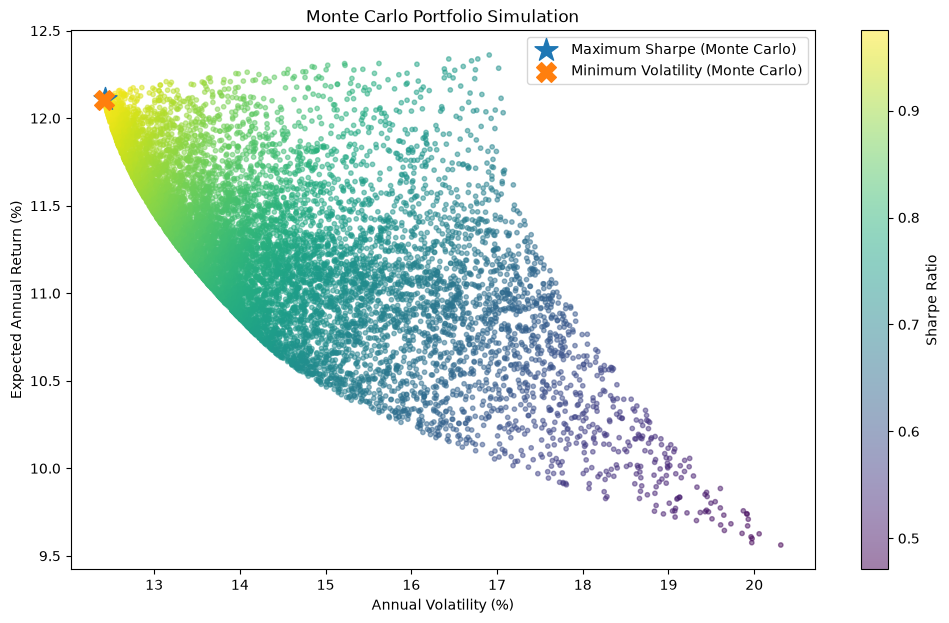

In [25]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.scatter(
    max_sharpe_portfolio_mc["Volatility"] * 100,
    max_sharpe_portfolio_mc["Return"] * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe (Monte Carlo)"
)

plt.scatter(
    min_vol_portfolio_mc["Volatility"] * 100,
    min_vol_portfolio_mc["Return"] * 100,
    marker="X",
    s=200,
    label="Minimum Volatility (Monte Carlo)"
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()

plt.show()

### Monte Carlo Interpretation

The simulation shows the set of risk-return combinations achievable using the three selected assets under long-only constraints.

The portfolios with the highest historical risk-adjusted performance are concentrated primarily in Gold and MSCI World, while Emerging Markets receives very little weight.

The Monte Carlo simulation provides an approximation of the optimal portfolios. In the following section, numerical optimization is used to solve the portfolio allocation problem directly.

## 7. Mean-Variance Portfolio Optimization

Monte Carlo simulation provides an approximation of the optimal portfolios by sampling random asset allocations.

To obtain more precise solutions, numerical optimization is used to directly solve two portfolio allocation problems:

1. **Minimum Volatility Portfolio:** minimizes portfolio risk.
2. **Maximum Sharpe Portfolio:** maximizes expected return per unit of volatility.

The optimization is subject to two constraints:

- Portfolio weights must sum to 100%.
- Short selling is not allowed, so each asset weight must remain between 0% and 100%.

In [26]:
def portfolio_return(weights):
    return weights @ expected_returns.values


def portfolio_volatility(weights):
    return np.sqrt(
        weights @ cov_matrix.values @ weights
    )

In [27]:
n_assets = len(expected_returns)

initial_weights = np.ones(n_assets) / n_assets

bounds = tuple(
    (0, 1) for _ in range(n_assets)
)

constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

In [28]:
min_vol_result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [29]:
min_vol_weights = min_vol_result.x

min_vol_exact = pd.Series(
    min_vol_weights,
    index=returns_clean.columns
)

min_vol_exact * 100

Ticker
Gold                5.290522e+01
Emerging Markets    1.008308e-15
World               4.709478e+01
dtype: float64

In [30]:
min_vol_return = portfolio_return(min_vol_weights)
min_vol_volatility = portfolio_volatility(min_vol_weights)

print("Expected Return:", min_vol_return * 100)
print("Volatility:", min_vol_volatility * 100)

Expected Return: 12.110064454375497
Volatility: 12.416587572632034


In [31]:
def negative_sharpe(weights):

    portfolio_ret = portfolio_return(weights)
    portfolio_vol = portfolio_volatility(weights)

    return -(portfolio_ret / portfolio_vol)

In [32]:
max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = max_sharpe_result.x

max_sharpe_exact = pd.Series(
    max_sharpe_weights,
    index=returns_clean.columns
)

max_sharpe_exact * 100

Ticker
Gold                51.582427
Emerging Markets     0.000000
World               48.417573
dtype: float64

In [33]:
max_sharpe_return = portfolio_return(
    max_sharpe_weights
)

max_sharpe_volatility = portfolio_volatility(
    max_sharpe_weights
)

max_sharpe_ratio = (
    max_sharpe_return /
    max_sharpe_volatility
)

print("Expected Return:", max_sharpe_return * 100)
print("Volatility:", max_sharpe_volatility * 100)
print("Sharpe Ratio:", max_sharpe_ratio)

Expected Return: 12.11683659948996
Volatility: 12.420052931347994
Sharpe Ratio: 0.9755865507551323


In [34]:
optimization_summary = pd.DataFrame({
    "Minimum Volatility": {
        "Gold Weight (%)": min_vol_exact["Gold"] * 100,
        "Emerging Markets Weight (%)": min_vol_exact["Emerging Markets"] * 100,
        "World Weight (%)": min_vol_exact["World"] * 100,
        "Expected Return (%)": min_vol_return * 100,
        "Volatility (%)": min_vol_volatility * 100,
        "Sharpe": min_vol_return / min_vol_volatility
    },

    "Maximum Sharpe": {
        "Gold Weight (%)": max_sharpe_exact["Gold"] * 100,
        "Emerging Markets Weight (%)": max_sharpe_exact["Emerging Markets"] * 100,
        "World Weight (%)": max_sharpe_exact["World"] * 100,
        "Expected Return (%)": max_sharpe_return * 100,
        "Volatility (%)": max_sharpe_volatility * 100,
        "Sharpe": max_sharpe_ratio
    }
})

optimization_summary

,Minimum Volatility,Maximum Sharpe
Gold Weight (%),5.290522e+01,51.582427
Emerging Markets Weight (%),1.008308e-15,0.000000
World Weight (%),4.709478e+01,48.417573
Expected Return (%),1.211006e+01,12.116837
Volatility (%),1.241659e+01,12.420053
Sharpe,9.753134e-01,0.975587


### Optimization Results

The numerical optimization produces two portfolios with very similar allocations.

Both portfolios allocate approximately half of the capital to Gold and half to MSCI World, while Emerging Markets receives almost no weight.

This result is consistent with the historical characteristics observed earlier:

- Gold and MSCI World achieved similar historical returns.
- Their correlation was relatively low.
- Emerging Markets exhibited lower returns, higher volatility, and a high correlation with MSCI World during the sample period.

The optimized allocations therefore exploit the diversification benefit between Gold and global equities.

However, these weights are highly dependent on historical estimates of returns and covariances. They should not be interpreted as recommended future allocations.

In [35]:
comparison = pd.DataFrame({
    "Monte Carlo Max Sharpe": [
        max_sharpe_portfolio_mc["Return"] * 100,
        max_sharpe_portfolio_mc["Volatility"] * 100,
        max_sharpe_portfolio_mc["Sharpe"]
    ],

    "Exact Max Sharpe": [
        max_sharpe_return * 100,
        max_sharpe_volatility * 100,
        max_sharpe_ratio
    ]
}, index=[
    "Expected Return (%)",
    "Volatility (%)",
    "Sharpe"
])

comparison

,Monte Carlo Max Sharpe,Exact Max Sharpe
Expected Return (%),12.109063,12.116837
Volatility (%),12.420644,12.420053
Sharpe,0.974914,0.975587


## 8. Efficient Frontier Optimization

The efficient frontier represents the set of portfolios offering the highest expected return for each level of risk.

Starting from the minimum-volatility portfolio, a sequence of target returns is defined. For each target return, numerical optimization is used to find the portfolio with the lowest possible volatility.

Only the upper branch starting from the global minimum-variance portfolio is considered efficient.

In [36]:
def minimize_volatility_for_target(target_return):

    constraints_target = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights: (
                portfolio_return(weights) - target_return
            )
        }
    )

    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_target
    )

    return result

In [37]:
frontier_start_return = min_vol_return
frontier_end_return = expected_returns.max()

target_returns = np.linspace(
    frontier_start_return,
    frontier_end_return,
    50
)

In [38]:
frontier_returns = []
frontier_volatilities = []
frontier_weights = []

for target in target_returns:

    result = minimize_volatility_for_target(target)

    if result.success:

        frontier_returns.append(target)

        frontier_volatilities.append(
            portfolio_volatility(result.x)
        )

        frontier_weights.append(result.x)

In [39]:
frontier_returns = np.array(frontier_returns)

frontier_volatilities = np.array(
    frontier_volatilities
)

frontier_weights = np.array(
    frontier_weights
)

print("Efficient frontier points:", len(frontier_returns))

Efficient frontier points: 50


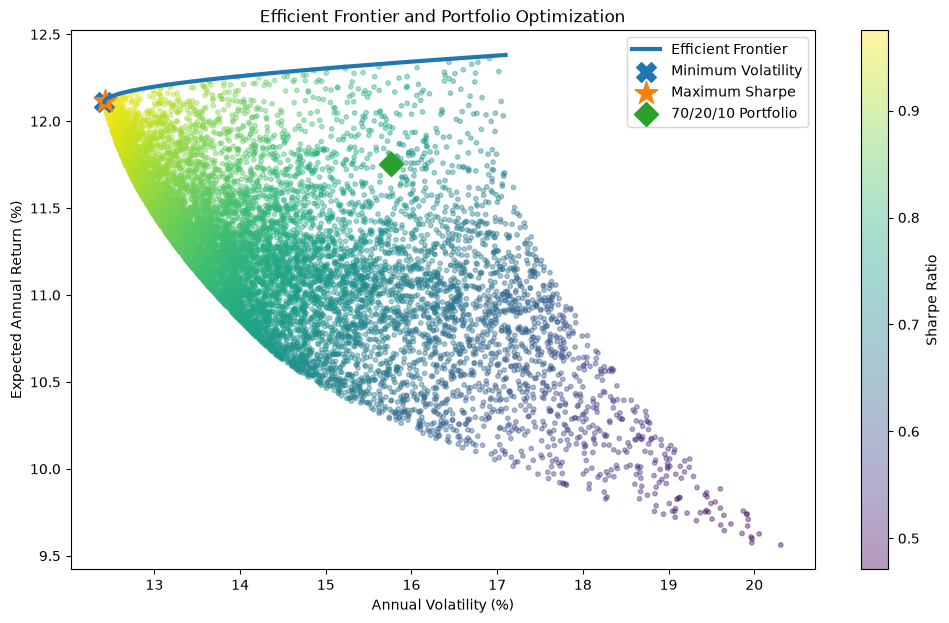

In [40]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.4,
    s=10
)

plt.plot(
    frontier_volatilities * 100,
    frontier_returns * 100,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    min_vol_volatility * 100,
    min_vol_return * 100,
    marker="X",
    s=200,
    label="Minimum Volatility"
)

plt.scatter(
    max_sharpe_volatility * 100,
    max_sharpe_return * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.scatter(
    portfolio_70_20_10_volatility * 100,
    portfolio_annual_mean_return * 100,
    marker="D",
    s=150,
    label="70/20/10 Portfolio"
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Efficient Frontier and Portfolio Optimization")

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.legend()

plt.show()

### Efficient Frontier Interpretation

The exact efficient frontier confirms the structure observed in the Monte Carlo simulation.

The minimum-volatility and maximum-Sharpe portfolios lie very close to one another and are both dominated by allocations to Gold and MSCI World.

The 70/20/10 reference portfolio lies inside the feasible portfolio set rather than on the efficient frontier. This indicates that, based on the historical estimates used in this analysis, other allocations offered a more favorable risk-return trade-off.

The results are strongly influenced by the selected sample period and by the use of historical mean returns and covariances as model inputs. Therefore, the optimized portfolios should be interpreted as an analysis of historical efficiency rather than as forecasts or investment recommendations.

## 9. Conclusions

This analysis illustrates how diversification and mean-variance optimization can be applied to a portfolio of global equities, emerging-market equities, and gold.

The main findings are:

- MSCI World generated the highest cumulative return over the selected period.
- Gold achieved a similar annualized growth rate with slightly lower volatility.
- Emerging Markets exhibited higher volatility and lower historical returns during the sample period.
- Gold showed low correlation with global equities, providing significant diversification benefits.
- The 70/20/10 reference portfolio reduced volatility compared with the individual assets.
- Both Monte Carlo simulation and numerical optimization favored portfolios concentrated in Gold and MSCI World.
- Numerical optimization produced more precise solutions than random portfolio simulation.

The analysis demonstrates the importance of considering both expected return and covariance when evaluating portfolio allocations.

Future extensions of the project will include drawdown analysis, historical backtesting, periodic contributions, and additional risk metrics.